# Advanced Analytics + Risk Metrics

## Day 6

This notebook performs:

1. Historical VaR and CVaR analysis
2. Rolling 90-day Sharpe ratio
3. Investor cohort analysis
4. SIP continuity analysis
5. Fund recommendation
6. Sector concentration using HHI
7. Advanced investment insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
nav = pd.read_csv("../Data/raw/02_nav_history.csv")

print(nav.shape)
print(nav.columns.tolist())
nav.head()

(46000, 3)
['amfi_code', 'date', 'nav']


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
# Convert date to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort data correctly
nav = nav.sort_values(["amfi_code", "date"])

# Check number of schemes
print("Number of schemes:", nav["amfi_code"].nunique())

# Check date range
print("Start date:", nav["date"].min())
print("End date:", nav["date"].max())

Number of schemes: 40
Start date: 2022-01-03 00:00:00
End date: 2026-05-29 00:00:00


In [4]:
# Calculate daily returns for each scheme
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Remove rows where return cannot be calculated
returns = nav.dropna(subset=["daily_return"]).copy()

print(returns.head())
print("Return rows:", len(returns))

      amfi_code       date       nav  daily_return
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
Return rows: 45960


In [5]:
# Historical VaR (95%) and CVaR (95%)
var_results = []

for amfi_code, group in returns.groupby("amfi_code"):

    daily_returns = group["daily_return"].dropna()

    # 95% Historical VaR = 5th percentile
    var_95 = np.percentile(daily_returns, 5)

    # CVaR = average of returns at or below VaR
    tail_returns = daily_returns[daily_returns <= var_95]

    cvar_95 = tail_returns.mean()

    var_results.append({
        "amfi_code": amfi_code,
        "VaR_95": var_95,
        "CVaR_95": cvar_95,
        "observations": len(daily_returns)
    })

var_cvar = pd.DataFrame(var_results)

print(var_cvar.head())
print("Number of schemes:", len(var_cvar))

   amfi_code    VaR_95   CVaR_95  observations
0     100016 -0.014364 -0.018060          1149
1     100025 -0.003793 -0.004994          1149
2     100033 -0.019034 -0.023456          1149
3     101206 -0.013282 -0.017439          1149
4     101207 -0.026021 -0.032459          1149
Number of schemes: 40


In [6]:
var_cvar["VaR_95_pct"] = var_cvar["VaR_95"] * 100
var_cvar["CVaR_95_pct"] = var_cvar["CVaR_95"] * 100

var_cvar.head()

,amfi_code,VaR_95,CVaR_95,observations,VaR_95_pct,CVaR_95_pct
0,100016,-0.014364,-0.018060,1149,-1.436364,-1.806021
1,100025,-0.003793,-0.004994,1149,-0.379325,-0.499376
2,100033,-0.019034,-0.023456,1149,-1.903354,-2.345576
3,101206,-0.013282,-0.017439,1149,-1.328166,-1.743943
4,101207,-0.026021,-0.032459,1149,-2.602125,-3.245906


In [7]:
fund_master = pd.read_csv("../Data/raw/01_fund_master.csv")

print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [8]:
# Keep only the required fund master columns
fund_info = fund_master[
    ["amfi_code", "scheme_name", "fund_house", "category", "plan", "risk_category"]
].copy()

# Merge fund information with VaR/CVaR results
var_cvar_report = var_cvar.merge(
    fund_info,
    on="amfi_code",
    how="left"
)

# Arrange columns
var_cvar_report = var_cvar_report[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "plan",
        "risk_category",
        "VaR_95_pct",
        "CVaR_95_pct",
        "observations"
    ]
]

print("Number of schemes:", len(var_cvar_report))
var_cvar_report.head()

Number of schemes: 40


,amfi_code,scheme_name,fund_house,category,plan,risk_category,VaR_95_pct,CVaR_95_pct,observations
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Regular,Moderate,-1.436364,-1.806021,1149
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,Regular,Low,-0.379325,-0.499376,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Regular,High,-1.903354,-2.345576,1149
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Regular,Moderate,-1.328166,-1.743943,1149
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Regular,Very High,-2.602125,-3.245906,1149


In [9]:
# Sort by VaR: most negative first
highest_var_risk = var_cvar_report.sort_values(
    "VaR_95_pct"
).head(10)

print("10 funds with highest downside risk:")
display(
    highest_var_risk[
        ["scheme_name", "VaR_95_pct", "CVaR_95_pct"]
    ]
)

10 funds with highest downside risk:


,scheme_name,VaR_95_pct,CVaR_95_pct
22,SBI Small Cap Fund - Direct Plan - Growth,-2.685944,-3.238412
17,Axis Small Cap Fund - Regular - Growth,-2.618842,-3.166729
4,ABSL Small Cap Fund - Regular - Growth,-2.602125,-3.245906
11,Nippon India Small Cap Fund - Regular - Growth,-2.543811,-3.230407
21,SBI Small Cap Fund - Regular Plan - Growth,-2.450705,-3.059526
39,DSP Small Cap Fund - Regular - Growth,-2.348307,-3.103625
7,UTI Mid Cap Fund - Regular - Growth,-1.922028,-2.325086
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-1.903354,-2.345576
25,ICICI Pru Midcap Fund - Regular - Growth,-1.889179,-2.434207
16,Axis Midcap Fund - Regular - Growth,-1.848028,-2.426006


In [10]:
highest_cvar_risk = var_cvar_report.sort_values(
    "CVaR_95_pct"
).head(10)

print("10 funds with worst CVaR:")
display(
    highest_cvar_risk[
        ["scheme_name", "VaR_95_pct", "CVaR_95_pct"]
    ]
)

10 funds with worst CVaR:


,scheme_name,VaR_95_pct,CVaR_95_pct
4,ABSL Small Cap Fund - Regular - Growth,-2.602125,-3.245906
22,SBI Small Cap Fund - Direct Plan - Growth,-2.685944,-3.238412
11,Nippon India Small Cap Fund - Regular - Growth,-2.543811,-3.230407
17,Axis Small Cap Fund - Regular - Growth,-2.618842,-3.166729
39,DSP Small Cap Fund - Regular - Growth,-2.348307,-3.103625
21,SBI Small Cap Fund - Regular Plan - Growth,-2.450705,-3.059526
25,ICICI Pru Midcap Fund - Regular - Growth,-1.889179,-2.434207
16,Axis Midcap Fund - Regular - Growth,-1.848028,-2.426006
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-1.903354,-2.345576
7,UTI Mid Cap Fund - Regular - Growth,-1.922028,-2.325086


In [11]:
# Create reports folder if it doesn't exist
Path("../reports").mkdir(parents=True, exist_ok=True)

# Export VaR/CVaR report
var_cvar_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("VaR/CVaR report saved successfully!")

VaR/CVaR report saved successfully!


In [12]:
check_report = pd.read_csv("../reports/var_cvar_report.csv")

print(check_report.shape)
print(check_report.columns.tolist())
check_report.head()

(40, 9)
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'risk_category', 'VaR_95_pct', 'CVaR_95_pct', 'observations']


,amfi_code,scheme_name,fund_house,category,plan,risk_category,VaR_95_pct,CVaR_95_pct,observations
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Regular,Moderate,-1.436364,-1.806021,1149
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,Regular,Low,-0.379325,-0.499376,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Regular,High,-1.903354,-2.345576,1149
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Regular,Moderate,-1.328166,-1.743943,1149
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Regular,Very High,-2.602125,-3.245906,1149


In [13]:
# Select 5 key funds for rolling Sharpe analysis
key_funds = (
    var_cvar_report
    .sort_values("VaR_95_pct")
    .head(5)["amfi_code"]
    .tolist()
)

print("Selected AMFI codes:", key_funds)

display(
    var_cvar_report[
        var_cvar_report["amfi_code"].isin(key_funds)
    ][["amfi_code", "scheme_name"]]
)

Selected AMFI codes: [119599, 119095, 101207, 118634, 119598]


,amfi_code,scheme_name
4,101207,ABSL Small Cap Fund - Regular - Growth
11,118634,Nippon India Small Cap Fund - Regular - Growth
17,119095,Axis Small Cap Fund - Regular - Growth
21,119598,SBI Small Cap Fund - Regular Plan - Growth
22,119599,SBI Small Cap Fund - Direct Plan - Growth


In [14]:
# Calculate 90-day rolling Sharpe ratio for the 5 selected funds

rolling_sharpe_data = []

for amfi_code in key_funds:

    fund_returns = (
        returns[returns["amfi_code"] == amfi_code]
        .sort_values("date")
        .copy()
    )

    # 90-day rolling mean
    rolling_mean = (
        fund_returns["daily_return"]
        .rolling(window=90)
        .mean()
    )

    # 90-day rolling standard deviation
    rolling_std = (
        fund_returns["daily_return"]
        .rolling(window=90)
        .std()
    )

    # Annualized rolling Sharpe ratio
    fund_returns["rolling_sharpe_90"] = (
        rolling_mean / rolling_std
    ) * np.sqrt(252)

    rolling_sharpe_data.append(
        fund_returns[
            ["amfi_code", "date", "rolling_sharpe_90"]
        ]
    )

rolling_sharpe = pd.concat(
    rolling_sharpe_data,
    ignore_index=True
)

# Remove the first 89 days where rolling Sharpe is unavailable
rolling_sharpe = rolling_sharpe.dropna(
    subset=["rolling_sharpe_90"]
)

print("Rolling Sharpe rows:", len(rolling_sharpe))
rolling_sharpe.head()

Rolling Sharpe rows: 5300


,amfi_code,date,rolling_sharpe_90
89,119599,2022-05-09,0.146690
90,119599,2022-05-10,0.565125
91,119599,2022-05-11,0.719262
92,119599,2022-05-12,0.638444
93,119599,2022-05-13,1.328024


In [15]:
# Add scheme names
rolling_sharpe = rolling_sharpe.merge(
    fund_info[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(rolling_sharpe.head())

   amfi_code       date  rolling_sharpe_90  \
0     119599 2022-05-09           0.146690   
1     119599 2022-05-10           0.565125   
2     119599 2022-05-11           0.719262   
3     119599 2022-05-12           0.638444   
4     119599 2022-05-13           1.328024   

                                 scheme_name  
0  SBI Small Cap Fund - Direct Plan - Growth  
1  SBI Small Cap Fund - Direct Plan - Growth  
2  SBI Small Cap Fund - Direct Plan - Growth  
3  SBI Small Cap Fund - Direct Plan - Growth  
4  SBI Small Cap Fund - Direct Plan - Growth  


In [16]:
# Summary of rolling Sharpe ratios
sharpe_summary = (
    rolling_sharpe
    .groupby("scheme_name")["rolling_sharpe_90"]
    .agg(["mean", "min", "max"])
    .round(3)
)

display(sharpe_summary)

,mean,min,max
scheme_name,,,
ABSL Small Cap Fund - Regular - Growth,0.416,-2.725,4.631
Axis Small Cap Fund - Regular - Growth,0.345,-3.911,4.929
Nippon India Small Cap Fund - Regular - Growth,0.672,-2.660,5.734
SBI Small Cap Fund - Direct Plan - Growth,0.133,-4.771,4.546
SBI Small Cap Fund - Regular Plan - Growth,1.009,-2.558,5.209


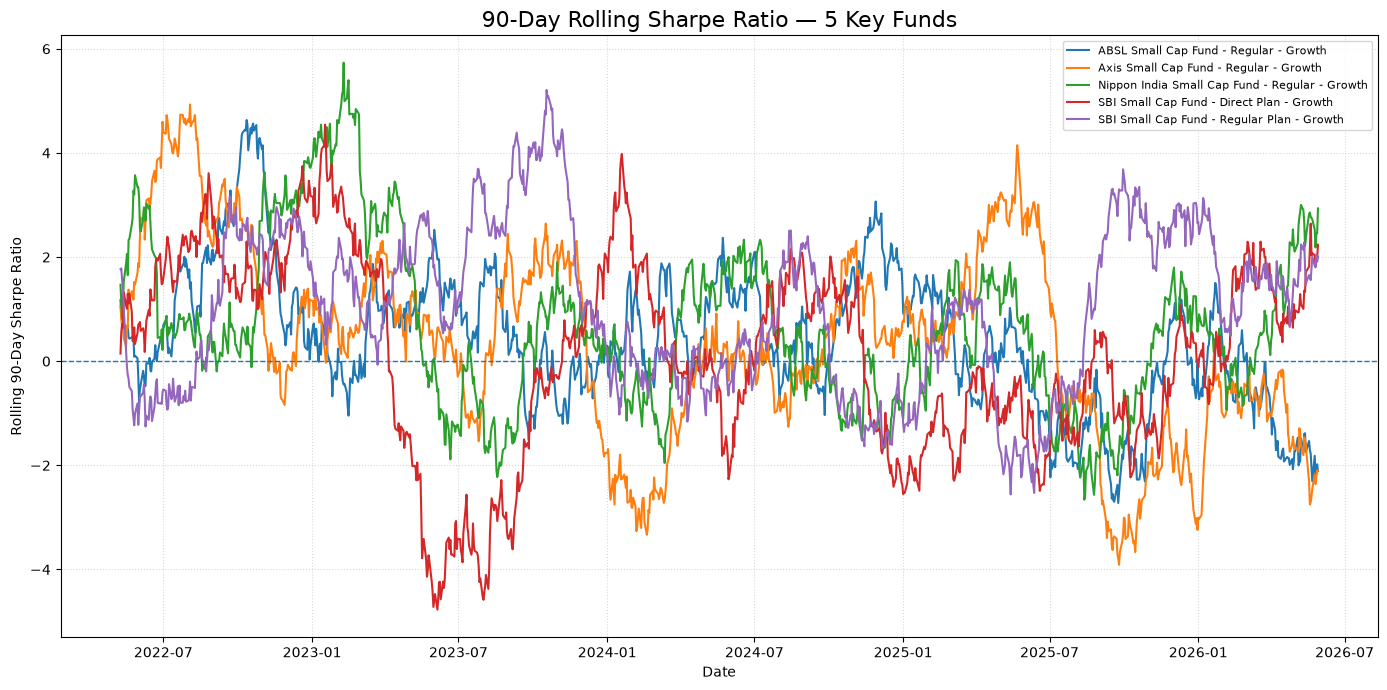

In [17]:
# Plot 90-day rolling Sharpe ratio

plt.figure(figsize=(14, 7))

for scheme_name, group in rolling_sharpe.groupby("scheme_name"):

    group = group.sort_values("date")

    plt.plot(
        group["date"],
        group["rolling_sharpe_90"],
        label=scheme_name,
        linewidth=1.5
    )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "90-Day Rolling Sharpe Ratio — 5 Key Funds",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Rolling 90-Day Sharpe Ratio")

plt.legend(
    loc="best",
    fontsize=8
)

plt.grid(
    True,
    linestyle=":",
    alpha=0.5
)

plt.tight_layout()

plt.show()

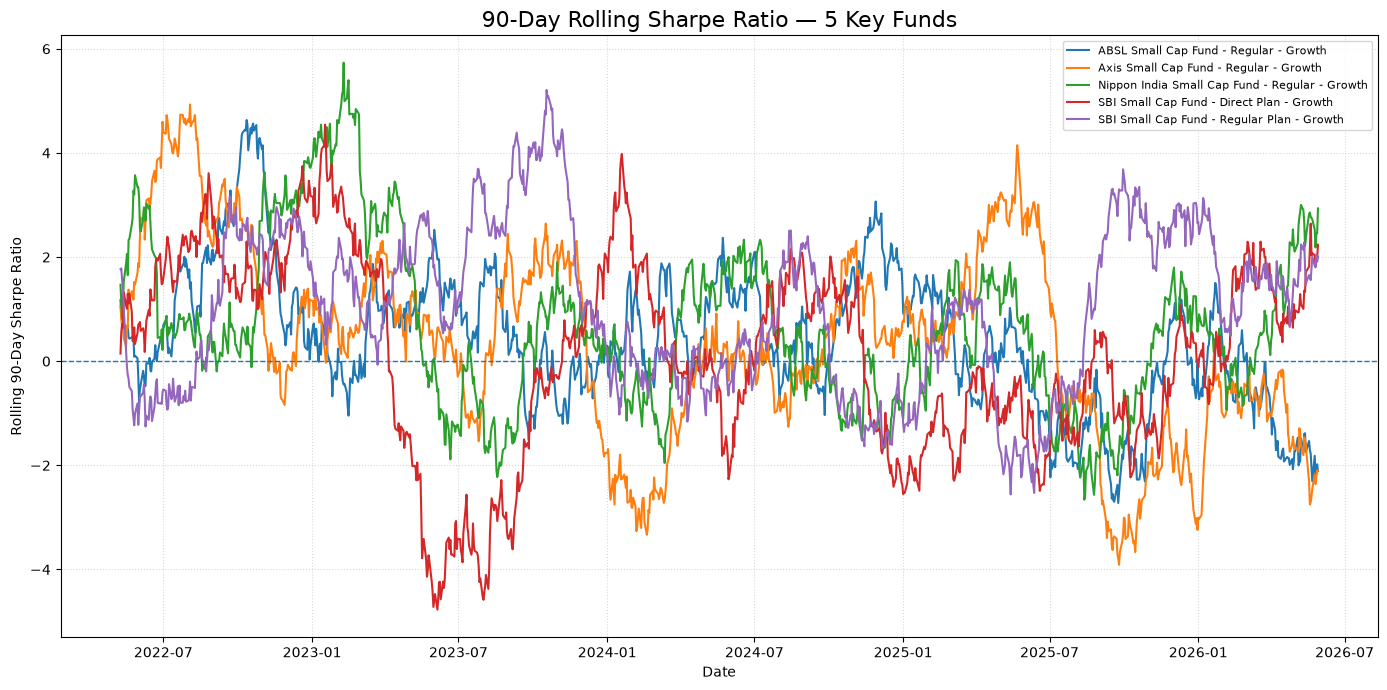

rolling_sharpe_chart.png saved successfully!


In [18]:
# Save rolling Sharpe chart

Path("../reports").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14, 7))

for scheme_name, group in rolling_sharpe.groupby("scheme_name"):

    group = group.sort_values("date")

    plt.plot(
        group["date"],
        group["rolling_sharpe_90"],
        label=scheme_name,
        linewidth=1.5
    )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "90-Day Rolling Sharpe Ratio — 5 Key Funds",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Rolling 90-Day Sharpe Ratio")

plt.legend(
    loc="best",
    fontsize=8
)

plt.grid(
    True,
    linestyle=":",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("rolling_sharpe_chart.png saved successfully!")

In [19]:
from pathlib import Path

chart_path = Path("../reports/rolling_sharpe_chart.png")

print("File exists:", chart_path.exists())

if chart_path.exists():
    print("Saved at:", chart_path.resolve())

File exists: True
Saved at: C:\Users\HP\Desktop\Mutual Fund Capstone Project\reports\rolling_sharpe_chart.png


In [21]:
import pandas as pd
from pathlib import Path

# Load investor transaction data
investor_transactions = pd.read_csv(
    "../Data/raw/08_investor_transactions.csv"
)

print("Shape:", investor_transactions.shape)
print("\nColumns:")
print(investor_transactions.columns.tolist())

display(investor_transactions.head())

Shape: (32778, 13)

Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [22]:
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"],
    errors="coerce"
)

print(investor_transactions["transaction_date"].dtype)
print("Missing dates:", investor_transactions["transaction_date"].isna().sum())

datetime64[us]
Missing dates: 0


In [23]:
first_transactions = (
    investor_transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transactions["first_transaction_year"] = (
    first_transactions["transaction_date"].dt.year
)

print("Number of investors:", len(first_transactions))

display(first_transactions.head(10))

Number of investors: 5000


,investor_id,transaction_date,first_transaction_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024
5,INV000006,2024-01-02,2024
6,INV000007,2024-01-03,2024
7,INV000008,2024-05-27,2024
8,INV000009,2024-01-10,2024
9,INV000010,2024-04-11,2024


In [24]:
cohort_data = investor_transactions.merge(
    first_transactions[
        ["investor_id", "first_transaction_year"]
    ],
    on="investor_id",
    how="left"
)

display(cohort_data.head())

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,first_transaction_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [25]:
print(
    cohort_data["first_transaction_year"]
    .value_counts()
    .sort_index()
)

first_transaction_year
2024    32499
2025      279
Name: count, dtype: int64


In [26]:
sip_transactions = cohort_data[
    cohort_data["transaction_type"].str.upper() == "SIP"
].copy()

cohort_sip = (
    sip_transactions
    .groupby("first_transaction_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

display(cohort_sip)

,first_transaction_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [27]:
fund_info = pd.read_csv(
    "../Data/raw/01_fund_master.csv"
)

print(fund_info.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [28]:
cohort_funds = cohort_data.merge(
    fund_info[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

display(
    cohort_funds[
        ["investor_id", "first_transaction_year",
         "amfi_code", "scheme_name"]
    ].head()
)

,investor_id,first_transaction_year,amfi_code,scheme_name
0,INV003054,2024,119092,Axis Bluechip Fund - Regular - Growth
1,INV002952,2024,148567,Mirae Asset Large Cap Fund - Regular - Growth
2,INV003420,2024,118636,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024,118634,Nippon India Small Cap Fund - Regular - Growth
4,INV004691,2024,119094,Axis Midcap Fund - Regular - Growth


In [30]:
# Calculate total invested amount by investor cohort

investment_transactions = cohort_data[
    cohort_data["transaction_type"]
    .str.upper()
    .isin(["SIP", "LUMPSUM"])
].copy()

print("Investment transactions:", len(investment_transactions))

cohort_investment = (
    investment_transactions
    .groupby("first_transaction_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested_amount")
)

display(cohort_investment)

Investment transactions: 27811


,first_transaction_year,total_invested_amount
0,2024,2258062304
1,2025,18992635


In [33]:
# Add fund names to cohort transactions

cohort_funds = cohort_data.merge(
    fund_info[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print("Rows:", len(cohort_funds))
display(
    cohort_funds[
        ["investor_id", "first_transaction_year",
         "amfi_code", "scheme_name"]
    ].head()
)

Rows: 32778


,investor_id,first_transaction_year,amfi_code,scheme_name
0,INV003054,2024,119092,Axis Bluechip Fund - Regular - Growth
1,INV002952,2024,148567,Mirae Asset Large Cap Fund - Regular - Growth
2,INV003420,2024,118636,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024,118634,Nippon India Small Cap Fund - Regular - Growth
4,INV004691,2024,119094,Axis Midcap Fund - Regular - Growth


In [34]:
# Find the most preferred fund for each investor cohort

fund_preference = (
    cohort_funds
    .groupby(
        ["first_transaction_year", "scheme_name"]
    )
    .size()
    .reset_index(name="transaction_count")
)

top_funds = (
    fund_preference
    .sort_values(
        ["first_transaction_year", "transaction_count"],
        ascending=[True, False]
    )
    .groupby("first_transaction_year")
    .head(1)
    .reset_index(drop=True)
)

print("Top fund for each cohort:")
display(top_funds)

Top fund for each cohort:


,first_transaction_year,scheme_name,transaction_count
0,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,ICICI Pru Liquid Fund - Regular - Growth,12


In [35]:
# Combine all cohort metrics

cohort_analysis = cohort_sip.merge(
    cohort_investment,
    on="first_transaction_year",
    how="outer"
)

cohort_analysis = cohort_analysis.merge(
    top_funds[
        [
            "first_transaction_year",
            "scheme_name",
            "transaction_count"
        ]
    ],
    on="first_transaction_year",
    how="left"
)

cohort_analysis = cohort_analysis.rename(
    columns={
        "scheme_name": "top_fund_preference",
        "transaction_count": "top_fund_transaction_count"
    }
)

cohort_analysis = cohort_analysis.sort_values(
    "first_transaction_year"
)

display(cohort_analysis)

,first_transaction_year,avg_sip_amount,total_invested_amount,top_fund_preference,top_fund_transaction_count
0,2024,10996.885825,2258062304,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,13505.209581,18992635,ICICI Pru Liquid Fund - Regular - Growth,12


In [36]:
from pathlib import Path

Path("../reports").mkdir(parents=True, exist_ok=True)

cohort_analysis.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("✅ cohort_analysis.csv saved successfully!")

✅ cohort_analysis.csv saved successfully!


In [37]:
# Select SIP transactions only
sip_data = investor_transactions[
    investor_transactions["transaction_type"].str.upper() == "SIP"
].copy()

# Make sure dates are datetime
sip_data["transaction_date"] = pd.to_datetime(
    sip_data["transaction_date"],
    errors="coerce"
)

# Remove invalid dates
sip_data = sip_data.dropna(subset=["transaction_date"])

print("Total SIP transactions:", len(sip_data))
print("Unique SIP investors:", sip_data["investor_id"].nunique())

Total SIP transactions: 19716
Unique SIP investors: 4762


In [38]:
sip_counts = (
    sip_data
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_transaction_count")
)

display(sip_counts.head())

,investor_id,sip_transaction_count
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


In [39]:
eligible_investors = sip_counts[
    sip_counts["sip_transaction_count"] >= 6
].copy()

print(
    "Investors with 6+ SIP transactions:",
    len(eligible_investors)
)

Investors with 6+ SIP transactions: 1362


In [40]:
eligible_sip = sip_data.merge(
    eligible_investors[["investor_id"]],
    on="investor_id",
    how="inner"
)

eligible_sip = eligible_sip.sort_values(
    ["investor_id", "transaction_date"]
)

display(eligible_sip.head(10))

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
1401,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified
1899,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified
2472,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified
3602,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified
8475,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified
9413,INV000004,2025-05-17,119599,SIP,2110,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified
2803,INV000008,2024-05-27,101206,SIP,8061,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified
3337,INV000008,2024-06-23,102887,SIP,55850,Punjab,Amritsar,B30,26-35,Female,18.6,Net Banking,Verified
6372,INV000008,2024-12-05,100025,SIP,425,Punjab,Amritsar,B30,26-35,Female,18.6,UPI,Verified
7241,INV000008,2025-01-18,119552,SIP,458,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified


In [41]:
eligible_sip["gap_days"] = (
    eligible_sip
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

display(
    eligible_sip[
        [
            "investor_id",
            "transaction_date",
            "gap_days"
        ]
    ].head(20)
)

,investor_id,transaction_date,gap_days
1401,INV000004,2024-03-16,NaN
1899,INV000004,2024-04-11,26.0
2472,INV000004,2024-05-09,28.0
3602,INV000004,2024-07-07,59.0
8475,INV000004,2025-03-29,265.0
9413,INV000004,2025-05-17,49.0
2803,INV000008,2024-05-27,NaN
3337,INV000008,2024-06-23,27.0
6372,INV000008,2024-12-05,165.0
7241,INV000008,2025-01-18,44.0


In [43]:
# SIP transactions only
sip_data = investor_transactions[
    investor_transactions["transaction_type"].str.upper() == "SIP"
].copy()

sip_data["transaction_date"] = pd.to_datetime(
    sip_data["transaction_date"],
    errors="coerce"
)

sip_data = sip_data.dropna(subset=["transaction_date"])

# Count SIP transactions per investor
sip_counts = (
    sip_data
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_transaction_count")
)

# Keep investors with 6 or more SIP transactions
eligible_investors = sip_counts[
    sip_counts["sip_transaction_count"] >= 6
].copy()

eligible_sip = sip_data.merge(
    eligible_investors[["investor_id"]],
    on="investor_id",
    how="inner"
)

eligible_sip = eligible_sip.sort_values(
    ["investor_id", "transaction_date"]
)

print("Eligible investors:", len(eligible_investors))
print("Eligible SIP transactions:", len(eligible_sip))

Eligible investors: 1362
Eligible SIP transactions: 9679


In [44]:
eligible_sip["gap_days"] = (
    eligible_sip
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

display(
    eligible_sip[
        ["investor_id", "transaction_date", "gap_days"]
    ].head(15)
)

,investor_id,transaction_date,gap_days
1401,INV000004,2024-03-16,NaN
1899,INV000004,2024-04-11,26.0
2472,INV000004,2024-05-09,28.0
3602,INV000004,2024-07-07,59.0
8475,INV000004,2025-03-29,265.0
9413,INV000004,2025-05-17,49.0
2803,INV000008,2024-05-27,NaN
3337,INV000008,2024-06-23,27.0
6372,INV000008,2024-12-05,165.0
7241,INV000008,2025-01-18,44.0


In [45]:
continuity_analysis = (
    eligible_sip
    .groupby("investor_id")
    .agg(
        sip_transaction_count=(
            "transaction_date",
            "count"
        ),
        avg_gap_days=(
            "gap_days",
            "mean"
        ),
        max_gap_days=(
            "gap_days",
            "max"
        )
    )
    .reset_index()
)

print("Continuity records:", len(continuity_analysis))

display(continuity_analysis.head(10))

Continuity records: 1362


,investor_id,sip_transaction_count,avg_gap_days,max_gap_days
0,INV000004,6,85.400000,265.0
1,INV000008,6,70.400000,165.0
2,INV000010,6,64.800000,139.0
3,INV000011,7,40.166667,125.0
4,INV000012,8,57.000000,132.0
5,INV000013,7,55.333333,104.0
6,INV000014,7,75.333333,128.0
7,INV000023,8,58.571429,115.0
8,INV000028,6,93.600000,238.0
9,INV000029,7,60.666667,96.0


In [46]:
continuity_analysis["continuity_status"] = np.where(
    continuity_analysis["avg_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

display(
    continuity_analysis.head(20)
)

,investor_id,sip_transaction_count,avg_gap_days,max_gap_days,continuity_status
0,INV000004,6,85.400000,265.0,At-Risk
1,INV000008,6,70.400000,165.0,At-Risk
2,INV000010,6,64.800000,139.0,At-Risk
3,INV000011,7,40.166667,125.0,At-Risk
4,INV000012,8,57.000000,132.0,At-Risk
5,INV000013,7,55.333333,104.0,At-Risk
6,INV000014,7,75.333333,128.0,At-Risk
7,INV000023,8,58.571429,115.0,At-Risk
8,INV000028,6,93.600000,238.0,At-Risk
9,INV000029,7,60.666667,96.0,At-Risk


In [47]:
total_eligible = len(continuity_analysis)

regular_investors = (
    continuity_analysis["continuity_status"]
    .eq("Regular")
    .sum()
)

at_risk_investors = (
    continuity_analysis["continuity_status"]
    .eq("At-Risk")
    .sum()
)

continuity_rate = regular_investors / total_eligible * 100
at_risk_rate = at_risk_investors / total_eligible * 100

print("Eligible investors:", total_eligible)
print("Regular investors:", regular_investors)
print("At-Risk investors:", at_risk_investors)
print(f"SIP continuity rate: {continuity_rate:.2f}%")
print(f"At-Risk rate: {at_risk_rate:.2f}%")

Eligible investors: 1362
Regular investors: 30
At-Risk investors: 1332
SIP continuity rate: 2.20%
At-Risk rate: 97.80%


In [48]:
from pathlib import Path

Path("../reports").mkdir(
    parents=True,
    exist_ok=True
)

continuity_analysis.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

print("✅ sip_continuity.csv saved successfully!")

✅ sip_continuity.csv saved successfully!


In [49]:
# Average rolling Sharpe for each fund
fund_sharpe = (
    rolling_sharpe
    .groupby(["amfi_code", "scheme_name"])["rolling_sharpe_90"]
    .mean()
    .reset_index(name="sharpe_ratio")
)

# Add fund risk category
fund_sharpe = fund_sharpe.merge(
    fund_info[
        ["amfi_code", "fund_house", "category", "risk_category"]
    ],
    on="amfi_code",
    how="left"
)

# Sort by Sharpe
fund_sharpe = fund_sharpe.sort_values(
    "sharpe_ratio",
    ascending=False
)

display(fund_sharpe.head(10))

,amfi_code,scheme_name,sharpe_ratio,fund_house,category,risk_category
3,119598,SBI Small Cap Fund - Regular Plan - Growth,1.009269,SBI Mutual Fund,Equity,Very High
1,118634,Nippon India Small Cap Fund - Regular - Growth,0.672272,Nippon India MF,Equity,Very High
0,101207,ABSL Small Cap Fund - Regular - Growth,0.416205,Aditya Birla Sun Life MF,Equity,Very High
2,119095,Axis Small Cap Fund - Regular - Growth,0.344639,Axis Mutual Fund,Equity,Very High
4,119599,SBI Small Cap Fund - Direct Plan - Growth,0.132516,SBI Mutual Fund,Equity,Very High


In [50]:
print(
    fund_sharpe["risk_category"]
    .value_counts(dropna=False)
)

risk_category
Very High    5
Name: count, dtype: int64


In [51]:
# Calculate annualized volatility for each fund

fund_risk = (
    returns
    .groupby("amfi_code")["daily_return"]
    .std()
    .mul(np.sqrt(252))
    .mul(100)
    .reset_index(name="annualized_risk_pct")
)

display(fund_risk.head())
print("Funds:", len(fund_risk))

,amfi_code,annualized_risk_pct
0,100016,14.548135
1,100025,3.905246
2,100033,18.936711
3,101206,14.568213
4,101207,25.797322


Funds: 40


In [52]:
fund_risk["risk_grade"] = pd.qcut(
    fund_risk["annualized_risk_pct"],
    q=3,
    labels=["Low", "Moderate", "High"],
    duplicates="drop"
)

display(
    fund_risk.sort_values("annualized_risk_pct")
)

,amfi_code,annualized_risk_pct,risk_grade
27,120507,0.493913,Low
5,101208,0.506437,Low
31,120844,0.513317,Low
1,100025,3.905246,Low
18,119120,3.967062,Low
13,118636,3.985538,Low
6,102885,12.836628,Low
12,118635,12.983159,Low
28,120841,13.463796,Low
19,119551,13.741434,Low


In [53]:
print(
    fund_risk["risk_grade"]
    .value_counts()
    .sort_index()
)

risk_grade
Low         14
Moderate    13
High        13
Name: count, dtype: int64


In [54]:
fund_sharpe = fund_sharpe.drop(
    columns=["risk_category"],
    errors="ignore"
)

fund_sharpe = fund_sharpe.merge(
    fund_risk[
        [
            "amfi_code",
            "annualized_risk_pct",
            "risk_grade"
        ]
    ],
    on="amfi_code",
    how="left"
)

display(
    fund_sharpe[
        [
            "scheme_name",
            "sharpe_ratio",
            "annualized_risk_pct",
            "risk_grade"
        ]
    ].head(10)
)

,scheme_name,sharpe_ratio,annualized_risk_pct,risk_grade
0,SBI Small Cap Fund - Regular Plan - Growth,1.009269,25.140579,High
1,Nippon India Small Cap Fund - Regular - Growth,0.672272,25.241521,High
2,ABSL Small Cap Fund - Regular - Growth,0.416205,25.797322,High
3,Axis Small Cap Fund - Regular - Growth,0.344639,25.066580,High
4,SBI Small Cap Fund - Direct Plan - Growth,0.132516,24.950125,High


In [55]:
def recommend_funds(risk_appetite):

    risk_appetite = risk_appetite.strip().title()

    valid_risks = ["Low", "Moderate", "High"]

    if risk_appetite not in valid_risks:
        raise ValueError(
            "Risk appetite must be Low, Moderate, or High."
        )

    result = (
        fund_sharpe[
            fund_sharpe["risk_grade"] == risk_appetite
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    return result[
        [
            "scheme_name",
            "fund_house",
            "category",
            "risk_grade",
            "annualized_risk_pct",
            "sharpe_ratio"
        ]
    ]

In [56]:
recommend_funds("Low")

,scheme_name,fund_house,category,risk_grade,annualized_risk_pct,sharpe_ratio


In [57]:
recommend_funds("Moderate")

,scheme_name,fund_house,category,risk_grade,annualized_risk_pct,sharpe_ratio


In [58]:
recommend_funds("High")

,scheme_name,fund_house,category,risk_grade,annualized_risk_pct,sharpe_ratio
0,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,High,25.140579,1.009269
1,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,High,25.241521,0.672272
2,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,High,25.797322,0.416205


In [60]:
import pandas as pd

portfolio_holdings = pd.read_csv(
    "../Data/raw/09_portfolio_holdings.csv"
)

print("Shape:", portfolio_holdings.shape)
print("Columns:", portfolio_holdings.columns.tolist())

display(portfolio_holdings.head())

Shape: (322, 8)
Columns: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [62]:
# Prepare holdings data for HHI calculation

hhi_data = portfolio_holdings[
    ["amfi_code", "sector", "weight_pct", "portfolio_date"]
].copy()

# Convert weight to numeric
hhi_data["weight_pct"] = pd.to_numeric(
    hhi_data["weight_pct"],
    errors="coerce"
)

# Remove invalid rows
hhi_data = hhi_data.dropna(
    subset=["amfi_code", "sector", "weight_pct"]
)

print("Rows after cleaning:", len(hhi_data))
display(hhi_data.head())

Rows after cleaning: 322


,amfi_code,sector,weight_pct,portfolio_date
0,119551,Utilities,13.85,2025-12-31
1,119551,Banking,11.19,2025-12-31
2,119551,Diversified,9.90,2025-12-31
3,119551,Pharma,4.76,2025-12-31
4,119551,Paints,10.25,2025-12-31


In [63]:
# Aggregate stock weights by sector within each fund

sector_weights = (
    hhi_data
    .groupby(["amfi_code", "sector"], as_index=False)["weight_pct"]
    .sum()
)

print("Sector-level records:", len(sector_weights))

display(sector_weights.head(10))

Sector-level records: 245


,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90
5,100016,NBFC,7.01
6,100016,Pharma,25.48
7,100016,Utilities,5.61
8,100033,Automobile,26.07
9,100033,Banking,35.97


In [64]:
# Convert percentage weights into decimal weights

sector_weights["weight_decimal"] = (
    sector_weights["weight_pct"] / 100
)

# Square each sector weight
sector_weights["weight_squared"] = (
    sector_weights["weight_decimal"] ** 2
)

display(sector_weights.head(10))

,amfi_code,sector,weight_pct,weight_decimal,weight_squared
0,100016,Automobile,14.84,0.1484,0.022023
1,100016,Banking,3.39,0.0339,0.001149
2,100016,Energy,6.09,0.0609,0.003709
3,100016,FMCG,11.68,0.1168,0.013642
4,100016,IT,25.90,0.2590,0.067081
5,100016,NBFC,7.01,0.0701,0.004914
6,100016,Pharma,25.48,0.2548,0.064923
7,100016,Utilities,5.61,0.0561,0.003147
8,100033,Automobile,26.07,0.2607,0.067964
9,100033,Banking,35.97,0.3597,0.129384


In [65]:
# Calculate HHI for each fund

hhi_by_fund = (
    sector_weights
    .groupby("amfi_code", as_index=False)["weight_squared"]
    .sum()
    .rename(columns={"weight_squared": "hhi"})
)

print("Number of funds:", len(hhi_by_fund))

display(
    hhi_by_fund.sort_values(
        "hhi",
        ascending=False
    ).head(10)
)

Number of funds: 34


,amfi_code,hhi
11,119092,0.296769
30,148569,0.254992
27,125498,0.253155
6,102887,0.251383
32,149323,0.241077
21,120505,0.238695
10,118635,0.237497
18,119599,0.232361
22,120506,0.231464
1,100033,0.227647


In [66]:
hhi_by_fund["hhi_10000"] = (
    hhi_by_fund["hhi"] * 10000
)

display(
    hhi_by_fund.sort_values(
        "hhi_10000",
        ascending=False
    ).head(10)
)

,amfi_code,hhi,hhi_10000
11,119092,0.296769,2967.6909
30,148569,0.254992,2549.9194
27,125498,0.253155,2531.5500
6,102887,0.251383,2513.8255
32,149323,0.241077,2410.7664
21,120505,0.238695,2386.9504
10,118635,0.237497,2374.9677
18,119599,0.232361,2323.6120
22,120506,0.231464,2314.6434
1,100033,0.227647,2276.4744


In [67]:
# Get fund names from fund master

fund_names = fund_master[
    ["amfi_code", "scheme_name", "fund_house", "category"]
].drop_duplicates("amfi_code")

hhi_analysis = hhi_by_fund.merge(
    fund_names,
    on="amfi_code",
    how="left"
)

display(
    hhi_analysis.sort_values(
        "hhi_10000",
        ascending=False
    ).head(10)
)

,amfi_code,hhi,hhi_10000,scheme_name,fund_house,category
11,119092,0.296769,2967.6909,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity
30,148569,0.254992,2549.9194,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity
27,125498,0.253155,2531.5500,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Equity
6,102887,0.251383,2513.8255,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity
32,149323,0.241077,2410.7664,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity
21,120505,0.238695,2386.9504,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
10,118635,0.237497,2374.9677,Nippon India ETF Nifty 50 BeES,Nippon India MF,Equity
18,119599,0.232361,2323.6120,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity
22,120506,0.231464,2314.6434,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Equity
1,100033,0.227647,2276.4744,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity


In [68]:
def classify_hhi(hhi):
    if hhi < 1000:
        return "Low"
    elif hhi <= 1800:
        return "Moderate"
    else:
        return "High"


hhi_analysis["concentration_level"] = (
    hhi_analysis["hhi_10000"]
    .apply(classify_hhi)
)

display(
    hhi_analysis[
        [
            "scheme_name",
            "fund_house",
            "category",
            "hhi_10000",
            "concentration_level"
        ]
    ]
    .sort_values("hhi_10000", ascending=False)
    .head(15)
)

,scheme_name,fund_house,category,hhi_10000,concentration_level
11,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity,2967.6909,High
30,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,2549.9194,High
27,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Equity,2531.5500,High
6,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,2513.8255,High
32,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,2410.7664,High
21,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,2386.9504,High
10,Nippon India ETF Nifty 50 BeES,Nippon India MF,Equity,2374.9677,High
18,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,2323.6120,High
22,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Equity,2314.6434,High
1,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,2276.4744,High


In [69]:
print(
    hhi_analysis["category"]
    .value_counts()
)

category
Equity    34
Name: count, dtype: int64


In [70]:
# Filter only Equity funds
equity_hhi = hhi_analysis[
    hhi_analysis["category"].str.strip().str.lower() == "equity"
].copy()

print("Equity funds:", len(equity_hhi))

display(
    equity_hhi[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "hhi_10000",
            "concentration_level"
        ]
    ]
    .sort_values("hhi_10000", ascending=False)
    .head(10)
)

Equity funds: 34


,amfi_code,scheme_name,fund_house,category,hhi_10000,concentration_level
11,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity,2967.6909,High
30,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,2549.9194,High
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Equity,2531.5500,High
6,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,2513.8255,High
32,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,2410.7664,High
21,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,2386.9504,High
10,118635,Nippon India ETF Nifty 50 BeES,Nippon India MF,Equity,2374.9677,High
18,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,2323.6120,High
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Equity,2314.6434,High
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,2276.4744,High


In [71]:
# Top 10 most concentrated equity funds
most_concentrated = equity_hhi.sort_values(
    "hhi_10000",
    ascending=False
).head(10)

print("MOST CONCENTRATED EQUITY FUNDS")
display(
    most_concentrated[
        ["scheme_name", "fund_house", "hhi_10000", "concentration_level"]
    ]
)

print("\nMOST DIVERSIFIED EQUITY FUNDS")
most_diversified = equity_hhi.sort_values(
    "hhi_10000",
    ascending=True
).head(10)

display(
    most_diversified[
        ["scheme_name", "fund_house", "hhi_10000", "concentration_level"]
    ]
)

MOST CONCENTRATED EQUITY FUNDS


,scheme_name,fund_house,hhi_10000,concentration_level
11,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,2967.6909,High
30,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,2549.9194,High
27,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,2531.5500,High
6,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,2513.8255,High
32,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,2410.7664,High
21,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,2386.9504,High
10,Nippon India ETF Nifty 50 BeES,Nippon India MF,2374.9677,High
18,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,2323.6120,High
22,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,2314.6434,High
1,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,2276.4744,High



MOST DIVERSIFIED EQUITY FUNDS


,scheme_name,fund_house,hhi_10000,concentration_level
5,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,1240.2024,Moderate
25,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,1362.0616,Moderate
15,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,1424.9104,Moderate
14,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,1595.8229,Moderate
9,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,1602.9924,Moderate
24,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,1620.6189,Moderate
26,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,1724.1088,Moderate
13,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,1751.0025,Moderate
2,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,1800.4225,High
0,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1805.8808,High


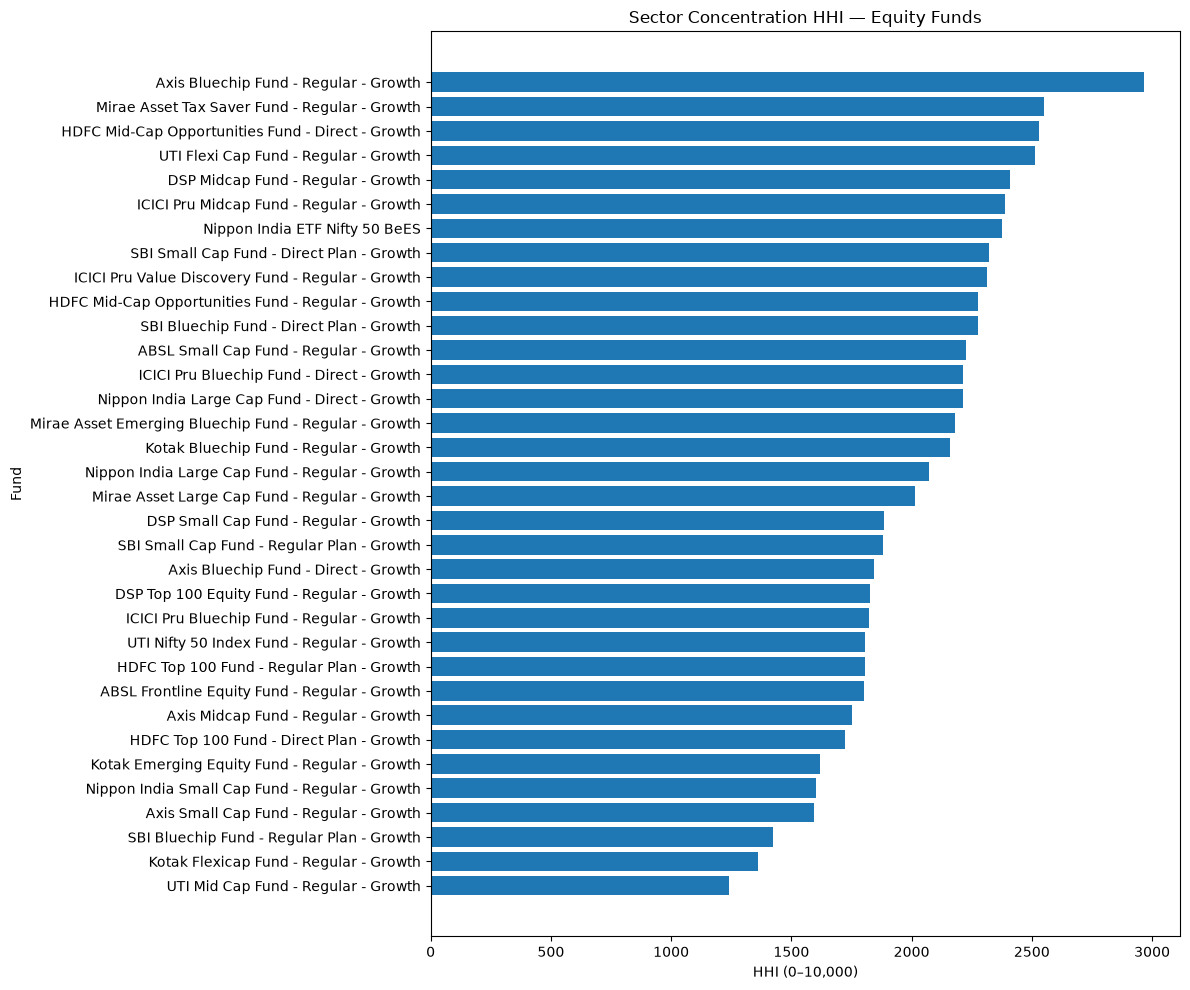

In [72]:
import matplotlib.pyplot as plt

plot_data = equity_hhi.sort_values(
    "hhi_10000",
    ascending=True
)

plt.figure(figsize=(12, 10))

plt.barh(
    plot_data["scheme_name"],
    plot_data["hhi_10000"]
)

plt.xlabel("HHI (0–10,000)")
plt.ylabel("Fund")
plt.title("Sector Concentration HHI — Equity Funds")

plt.tight_layout()

plt.savefig(
    "hhi_sector_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
print("HHI SUMMARY — EQUITY FUNDS")
print("--------------------------------")

print("Number of equity funds:", len(equity_hhi))
print("Average HHI:", round(equity_hhi["hhi_10000"].mean(), 2))
print("Minimum HHI:", round(equity_hhi["hhi_10000"].min(), 2))
print("Maximum HHI:", round(equity_hhi["hhi_10000"].max(), 2))

print("\nConcentration distribution:")
print(
    equity_hhi["concentration_level"]
    .value_counts()
)

HHI SUMMARY — EQUITY FUNDS
--------------------------------
Number of equity funds: 34
Average HHI: 2029.29
Minimum HHI: 1240.2
Maximum HHI: 2967.69

Concentration distribution:
concentration_level
High        26
Moderate     8
Name: count, dtype: int64


In [74]:
equity_hhi.to_csv(
    "sector_hhi_analysis.csv",
    index=False
)

print("Saved: sector_hhi_analysis.csv")
print("Saved: hhi_sector_concentration.png")

Saved: sector_hhi_analysis.csv
Saved: hhi_sector_concentration.png


In [76]:
print("Cohort Analysis Columns:")
print(cohort_analysis.columns.tolist())

display(cohort_analysis.head())

Cohort Analysis Columns:
['first_transaction_year', 'avg_sip_amount', 'total_invested_amount', 'top_fund_preference', 'top_fund_transaction_count']


,first_transaction_year,avg_sip_amount,total_invested_amount,top_fund_preference,top_fund_transaction_count
0,2024,10996.885825,2258062304,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,13505.209581,18992635,ICICI Pru Liquid Fund - Regular - Growth,12


In [77]:
print("\n2. INVESTOR COHORTS")
print("-" * 40)

display(
    cohort_analysis.sort_values(
        "total_invested_amount",
        ascending=False
    ).head(10)
)


2. INVESTOR COHORTS
----------------------------------------


,first_transaction_year,avg_sip_amount,total_invested_amount,top_fund_preference,top_fund_transaction_count
0,2024,10996.885825,2258062304,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,13505.209581,18992635,ICICI Pru Liquid Fund - Regular - Growth,12


In [78]:
print(var_cvar_report.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'risk_category', 'VaR_95_pct', 'CVaR_95_pct', 'observations']


In [79]:
highest_var = var_cvar_report.sort_values(
    "VaR_95_pct",
    ascending=True
).head(5)

print("Top 5 funds with highest downside VaR:")
display(
    highest_var[
        [
            "scheme_name",
            "VaR_95_pct",
            "CVaR_95_pct"
        ]
    ]
)

Top 5 funds with highest downside VaR:


,scheme_name,VaR_95_pct,CVaR_95_pct
22,SBI Small Cap Fund - Direct Plan - Growth,-2.685944,-3.238412
17,Axis Small Cap Fund - Regular - Growth,-2.618842,-3.166729
4,ABSL Small Cap Fund - Regular - Growth,-2.602125,-3.245906
11,Nippon India Small Cap Fund - Regular - Growth,-2.543811,-3.230407
21,SBI Small Cap Fund - Regular Plan - Growth,-2.450705,-3.059526


In [80]:
top_cohorts = cohort_analysis.sort_values(
    "total_invested_amount",
    ascending=False
)

print("Investor cohorts ranked by total invested amount:")
display(top_cohorts)

Investor cohorts ranked by total invested amount:


,first_transaction_year,avg_sip_amount,total_invested_amount,top_fund_preference,top_fund_transaction_count
0,2024,10996.885825,2258062304,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,13505.209581,18992635,ICICI Pru Liquid Fund - Regular - Growth,12


In [81]:
print("SIP Continuity Analysis")
print("-" * 40)

status_counts = (
    continuity_analysis["continuity_status"]
    .value_counts()
)

display(status_counts)

continuity_rate = (
    continuity_analysis["continuity_status"]
    .eq("Regular")
    .mean() * 100
)

at_risk_rate = (
    continuity_analysis["continuity_status"]
    .eq("At-Risk")
    .mean() * 100
)

print(f"Regular SIP continuity rate: {continuity_rate:.2f}%")
print(f"At-Risk investor rate: {at_risk_rate:.2f}%")

SIP Continuity Analysis
----------------------------------------


continuity_status
At-Risk    1332
Regular      30
Name: count, dtype: int64

Regular SIP continuity rate: 2.20%
At-Risk investor rate: 97.80%


In [82]:
print("LOW RISK")
display(recommend_funds("Low"))

print("\nMODERATE RISK")
display(recommend_funds("Moderate"))

print("\nHIGH RISK")
display(recommend_funds("High"))

LOW RISK


,scheme_name,fund_house,category,risk_grade,annualized_risk_pct,sharpe_ratio



MODERATE RISK


,scheme_name,fund_house,category,risk_grade,annualized_risk_pct,sharpe_ratio



HIGH RISK


,scheme_name,fund_house,category,risk_grade,annualized_risk_pct,sharpe_ratio
0,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,High,25.140579,1.009269
1,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,High,25.241521,0.672272
2,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,High,25.797322,0.416205


In [83]:
print("Top 5 Most Concentrated Equity Funds")
print("-" * 40)

display(
    equity_hhi
    .sort_values(
        "hhi_10000",
        ascending=False
    )[
        [
            "scheme_name",
            "hhi_10000",
            "concentration_level"
        ]
    ]
    .head(5)
)

Top 5 Most Concentrated Equity Funds
----------------------------------------


,scheme_name,hhi_10000,concentration_level
11,Axis Bluechip Fund - Regular - Growth,2967.6909,High
30,Mirae Asset Tax Saver Fund - Regular - Growth,2549.9194,High
27,HDFC Mid-Cap Opportunities Fund - Direct - Growth,2531.5500,High
6,UTI Flexi Cap Fund - Regular - Growth,2513.8255,High
32,DSP Midcap Fund - Regular - Growth,2410.7664,High


## 1. Highest Downside Risk

The Historical VaR analysis identifies **[Fund Name]** as having the highest downside risk, with a 95% VaR of **[X]%** and CVaR of **[Y]%**. This indicates that during the worst 5% of trading days, the fund experienced particularly severe negative returns.

## 2. Investor Cohort Behaviour

The **[YEAR] cohort** recorded the highest total investment of approximately **₹[X]**, indicating that investors entering during this period contributed the largest investment volume. Their most preferred fund was **[Fund Name]**.

## 3. SIP Continuity

Among investors with at least six SIP transactions, **[X]%** are classified as regular while **[Y]%** are classified as at-risk because their average SIP gap exceeds 35 days. This indicates an opportunity for targeted SIP retention campaigns.

## 4. Risk-Based Recommendations

For high-risk investors, **[Fund 1]**, **[Fund 2]**, and **[Fund 3]** achieved the highest Sharpe ratios within the High risk grade. This demonstrates how the recommender can identify funds offering stronger risk-adjusted performance within a selected risk category.

## 5. Sector Concentration

**[Fund Name]** has the highest sector HHI among the 34 equity funds, indicating the greatest concentration of portfolio exposure across sectors. Funds with lower HHI values have more diversified sector exposure and potentially lower concentration risk.